I0000 00:00:1775226165.779791   84494 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.11/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


🚀 Program started...
当前列名: Index(['year', 'female_ratio', 'male_ratio'], dtype='str')

Data statistics:
       female_ratio  male_ratio
count      29.00000    29.00000
mean        4.81000    95.19000
std         2.09276     2.09276
min         0.00000    91.57000
25%         3.37000    93.44000
50%         4.84000    95.16000
75%         6.56000    96.63000
max         8.43000   100.00000

📊 Female and male ratio per year：
1992: Female = 4.76%, Male = 95.24%
1993: Female = 7.69%, Male = 92.31%
1994: Female = 2.94%, Male = 97.06%
1995: Female = 5.80%, Male = 94.20%
1996: Female = 3.61%, Male = 96.39%
1997: Female = 2.78%, Male = 97.22%
1998: Female = 2.86%, Male = 97.14%
1999: Female = 6.25%, Male = 93.75%
2000: Female = 6.67%, Male = 93.33%
2001: Female = 5.26%, Male = 94.74%
2002: Female = 4.00%, Male = 96.00%
2003: Female = 6.98%, Male = 93.02%
2004: Female = 4.84%, Male = 95.16%
2005: Female = 3.45%, Male = 96.55%
2006: Female = 1.82%, Male = 98.18%
2007: Female = 3.57%, Male = 96.4

E0000 00:00:1775226171.302770   84494 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1775226171.302808   84494 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1775226171.302826   84494 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1775226171.302838   84494 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1775226171.302840   84494 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: 90840869036a
I0000 00:00:1775226171.302843   84494 cuda_diagnostics.cc:183] hostname: 90840869036a
I0000 00:00:1775226171.302940   84494 cuda_diagnostics.cc:190] libcuda reported version is: 580.95.5
I0000 00:00:1775226171.302957   84494 cuda_diagnostics.cc:194] kern

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.1625 - mae: 0.4624 - val_loss: 0.2465 - val_mae: 0.5779 - learning_rate: 0.0010
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1580 - mae: 0.4555 - val_loss: 0.2471 - val_mae: 0.5820 - learning_rate: 0.0010
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1553 - mae: 0.4519 - val_loss: 0.2466 - val_mae: 0.5834 - learning_rate: 0.0010
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1537 - mae: 0.4508 - val_loss: 0.2451 - val_mae: 0.5838 - learning_rate: 0.0010
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1505 - mae: 0.4411 - val_loss: 0.2443 - val_mae: 0.5834 - learning_rate: 0.0010
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1489 - mae: 0.4392 - val_loss: 0.2441 - val_mae: 0.5874 - learning_rate: 0.0010
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1449 - mae: 0.4328 - val_loss: 0.2448 - val_mae: 0.5914 - learning_rate: 0.0010
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s

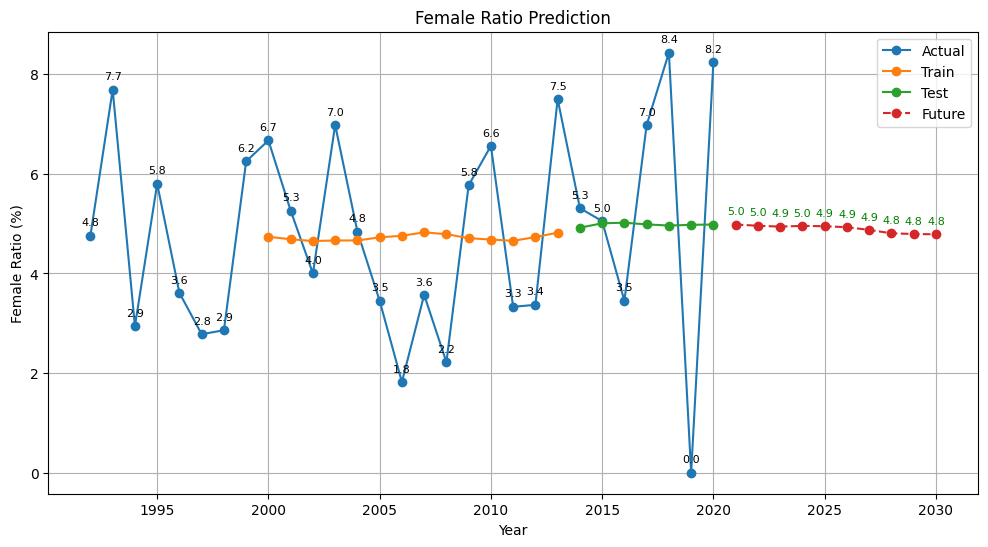

In [1]:
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random

# ================= 固定随机种子 =================
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# ================= 数据预处理 =================
def preprocess_data(file_path):
    df = pd.read_csv(file_path)

    # ✅ 自动兼容你的CSV列名
    df = df.rename(columns={
        'female_ratio (%)': 'female_ratio',
        'male_ratio (%)': 'male_ratio'
    })

    print("当前列名:", df.columns)

    df = df.sort_values('year')

    # 删除缺失值
    df = df.dropna(subset=['female_ratio', 'male_ratio'])

    # 防止0值
    df['male_ratio'] = df['male_ratio'].replace(0, 1e-8)

    # ❗ 已经是百分比，不要再乘100
    df['female_percent'] = df['female_ratio']

    # 特征工程
    df['female_diff'] = df['female_percent'].diff().fillna(0)
    df['female_trend_3'] = df['female_percent'].rolling(3, min_periods=1).mean()

    # 时间特征
    min_year = df['year'].min()
    df['year_progress'] = (df['year'] - min_year) / (df['year'].max() - min_year)
    df['year_sin'] = np.sin(2 * np.pi * (df['year'] - min_year)/10)
    df['year_cos'] = np.cos(2 * np.pi * (df['year'] - min_year)/10)

    features = [
        'female_percent', 'female_diff', 'female_trend_3',
        'year_progress', 'year_sin', 'year_cos'
    ]

    return df, features

# ================= 标准化 =================
def normalize_data(data, features):
    scaler = RobustScaler()
    data[features] = scaler.fit_transform(data[features])
    return data, scaler

# ================= 构建序列 =================
def create_sequences(data, features, sequence_length=8):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[features].iloc[i:i+sequence_length].values)
        y.append(data[features].iloc[i+sequence_length].values)
    return np.array(X), np.array(y)

# ================= LSTM模型 =================
def build_model(input_shape, num_features):
    model = Sequential([
        LSTM(32,
             activation='tanh',
             recurrent_activation='sigmoid',
             dropout=0.2,
             recurrent_dropout=0.2,   # ⭐关键！！！
             return_sequences=True),

        LSTM(16,
             activation='tanh',
             recurrent_activation='sigmoid',
             dropout=0.2,
             recurrent_dropout=0.2),  # ⭐关键！！！

        Dense(8, activation='relu'),
        Dense(num_features)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss=Huber(),
        metrics=['mae']
    )
    return model

# ================= 模型评估 =================
def safe_evaluate(model, X, y, scaler, feature_index=0):
    predictions = model.predict(X, verbose=0)

    dummy_pred = np.zeros_like(predictions)
    dummy_true = np.zeros_like(y)

    dummy_pred[:, feature_index] = predictions[:, feature_index]
    dummy_true[:, feature_index] = y[:, feature_index]

    pred = scaler.inverse_transform(dummy_pred)[:, feature_index]
    true = scaler.inverse_transform(dummy_true)[:, feature_index]

    mask = ~np.isnan(pred) & ~np.isnan(true)
    pred = pred[mask]
    true = true[mask]

    epsilon = np.abs(true).mean() * 0.1 + 1e-8

    metrics = {
        'MAE': mean_absolute_error(true, pred),
        'RMSE': np.sqrt(mean_squared_error(true, pred)),
        'sMAPE': 100 * np.mean(2 * np.abs(pred - true) / (np.abs(pred) + np.abs(true) + epsilon))
    }

    return metrics, pred

# ================= 未来预测 =================
def predict_future(model, last_sequence, scaler, future_steps=10):
    future_predictions = []
    current_sequence = last_sequence.copy()

    for _ in range(future_steps):
        pred = model.predict(current_sequence.reshape(1, *current_sequence.shape), verbose=0)[0]
        future_predictions.append(pred)
        current_sequence = np.vstack([current_sequence[1:], pred])

    dummy = np.zeros((len(future_predictions), len(scaler.scale_)))
    dummy[:, 0] = [x[0] for x in future_predictions]

    return scaler.inverse_transform(dummy)[:, 0]

# ================= 可视化 =================
def plot_results(df, train_pred, test_pred, future_pred, sequence_length):
    plt.figure(figsize=(12,6))

    # ===== 实际值 =====
    plt.plot(df['year'], df['female_ratio'], 'o-', label="Actual")

    # 👉 历史数据标注
    for x, y in zip(df['year'], df['female_ratio']):
        plt.text(x, y + 0.2, f"{y:.1f}", fontsize=8, ha='center')

    # ===== 训练集 =====
    train_years = df['year'].iloc[sequence_length:sequence_length+len(train_pred)]
    plt.plot(train_years, train_pred, 'o-', label="Train")

    # ===== 测试集 =====
    test_years = df['year'].iloc[
        sequence_length+len(train_pred):
        sequence_length+len(train_pred)+len(test_pred)
    ]
    plt.plot(test_years, test_pred, 'o-', label="Test")

    # ===== 未来预测 =====
    future_years = list(range(df['year'].iloc[-1]+1,
                             df['year'].iloc[-1]+1+len(future_pred)))
    plt.plot(future_years, future_pred, 'o--', label="Future")

    # 👉 未来预测标注
    for x, y in zip(future_years, future_pred):
        plt.text(x, y + 0.2, f"{y:.1f}", fontsize=8, color='green', ha='center')

    # ===== 图设置 =====
    plt.xlabel("Year")
    plt.ylabel("Female Ratio (%)")
    plt.title("Female Ratio Prediction")
    plt.legend()
    plt.grid(True)

    plt.show()
# ================= 主程序 =================
def main():
    print("🚀 Program started...")

    # ✅ 先生成 df
    df, features = preprocess_data("female_male_ratio.csv")

    print("\nData statistics:")
    print(df[['female_ratio', 'male_ratio']].describe())

    # ✅ 再用 df
    print("\n📊 Female and male ratio per year：")
    for _, row in df.iterrows():
        print(f"{int(row['year'])}: Female = {row['female_ratio']:.2f}%, Male = {row['male_ratio']:.2f}%")

    # ✅ 后面继续
    df, scaler = normalize_data(df, features)

    sequence_length = 8
    X, y = create_sequences(df, features, sequence_length)

    test_size = len(X) // 3
    X_train, X_test = X[:-test_size], X[-test_size:]
    y_train, y_test = y[:-test_size], y[-test_size:]

    model = build_model((sequence_length, len(features)), len(features))

    print("\n⏳ Starting model training...")
    history = model.fit(
        X_train, y_train,
        epochs=50,   # ✅ 先用50测试
        batch_size=2,
        validation_data=(X_test, y_test),
        callbacks=[
            EarlyStopping(patience=20, restore_best_weights=True),
            ReduceLROnPlateau(patience=10)
        ],
        verbose=1
    )

    print("\n📊 Model Evaluation")
    train_metrics, train_pred = safe_evaluate(model, X_train, y_train, scaler)
    test_metrics, test_pred = safe_evaluate(model, X_test, y_test, scaler)

    print("Train Set:", train_metrics)
    print("Test Set:", test_metrics)

    future_pred = predict_future(model, X[-1], scaler, 10)

    print("\n📈 Future Predictions:")
    for i, val in enumerate(future_pred):
        print(f"{df['year'].iloc[-1]+1+i}: {val:.2f}%")

    plot_results(df, train_pred, test_pred, future_pred, sequence_length)
    
# ================= 运行 =================
if __name__ == "__main__":
    main()